# Time Series Forecasting Tutorial
## Using Machine Learning to Forecast Energy Consumption

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [6]:
df = pd.read_csv('PJME_hourly.csv')
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

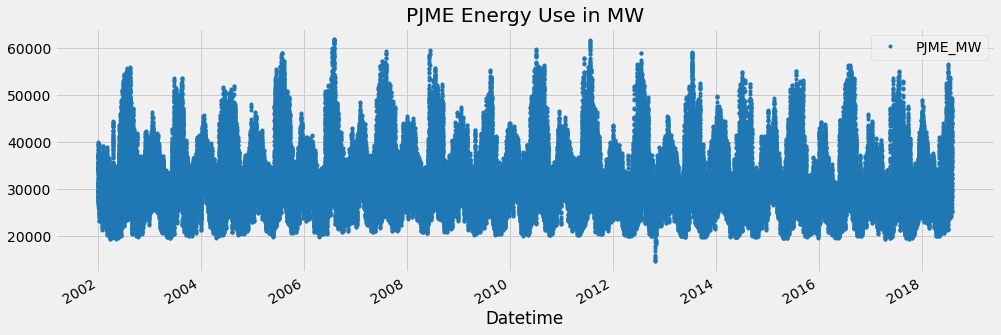

In [7]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

# Train / Test Split

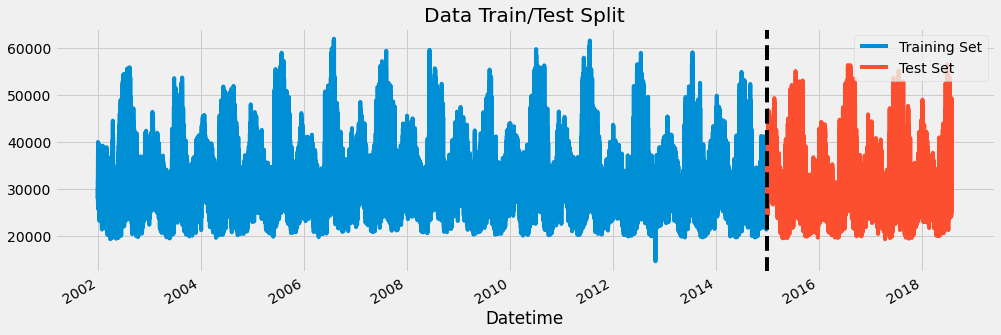

In [8]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

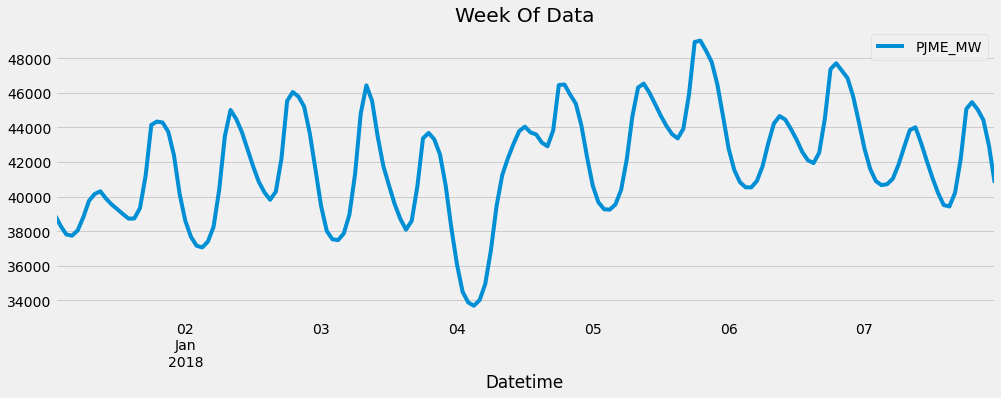

In [9]:
df = df.sort_index()

df.loc[(df.index > '2018-01-01') & (df.index < '2018-01-08')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()


# Feature Creation
https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html

In [10]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# Visualize our Feature / Target Relationship

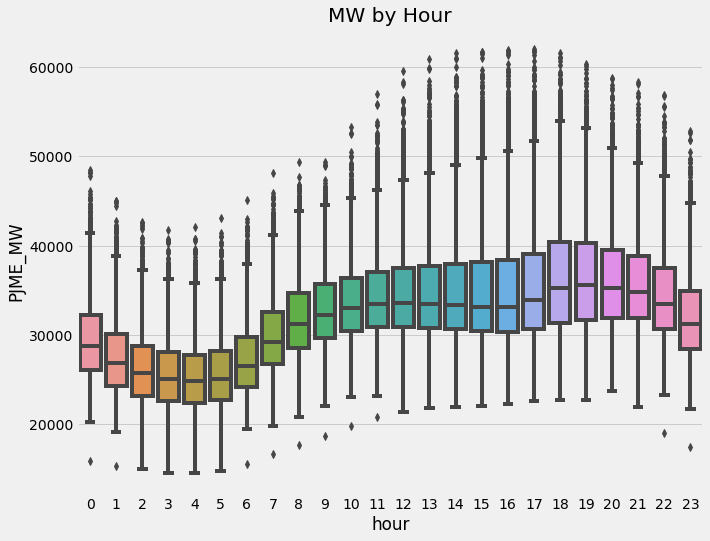

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

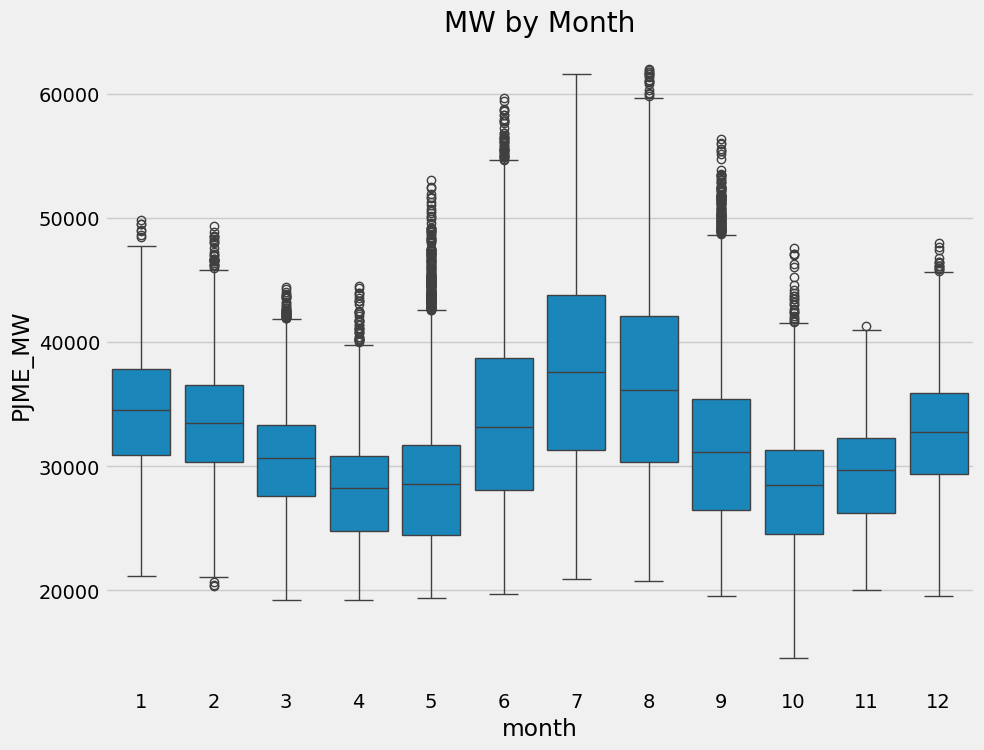

In [85]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW')
ax.set_title('MW by Month')
plt.show()

# Create our Model

In [12]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [13]:
reg = xgb.XGBRegressor(n_estimators=1000,
                #       early_stopping_rounds=50,
                #       max_depth=3,
                #       learning_rate=0.01
                      )
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=True)

[0]	validation_0-rmse:5179.23300	validation_1-rmse:5359.30943
[1]	validation_0-rmse:4375.01962	validation_1-rmse:4687.00132
[2]	validation_0-rmse:3874.17400	validation_1-rmse:4279.28898
[3]	validation_0-rmse:3572.89245	validation_1-rmse:4082.60841
[4]	validation_0-rmse:3372.17780	validation_1-rmse:3952.54672
[5]	validation_0-rmse:3247.62891	validation_1-rmse:3881.05746
[6]	validation_0-rmse:3162.64310	validation_1-rmse:3856.13245
[7]	validation_0-rmse:3073.82520	validation_1-rmse:3790.13994
[8]	validation_0-rmse:3021.60497	validation_1-rmse:3790.80157
[9]	validation_0-rmse:2967.30458	validation_1-rmse:3762.76936
[10]	validation_0-rmse:2888.42820	validation_1-rmse:3765.37637
[11]	validation_0-rmse:2870.15625	validation_1-rmse:3759.06623
[12]	validation_0-rmse:2813.33663	validation_1-rmse:3779.46019
[13]	validation_0-rmse:2779.04333	validation_1-rmse:3817.51231
[14]	validation_0-rmse:2760.93139	validation_1-rmse:3808.04851
[15]	validation_0-rmse:2739.22479	validation_1-rmse:3798.04910
[1

[130]	validation_0-rmse:1532.87716	validation_1-rmse:4254.73932
[131]	validation_0-rmse:1531.74257	validation_1-rmse:4256.52830
[132]	validation_0-rmse:1529.89719	validation_1-rmse:4256.93679
[133]	validation_0-rmse:1529.01628	validation_1-rmse:4256.38000
[134]	validation_0-rmse:1524.83589	validation_1-rmse:4264.24711
[135]	validation_0-rmse:1521.42064	validation_1-rmse:4265.35226
[136]	validation_0-rmse:1518.32466	validation_1-rmse:4266.73698
[137]	validation_0-rmse:1514.46718	validation_1-rmse:4268.16049
[138]	validation_0-rmse:1511.66135	validation_1-rmse:4268.45489
[139]	validation_0-rmse:1504.72626	validation_1-rmse:4268.55234
[140]	validation_0-rmse:1501.34655	validation_1-rmse:4272.19075
[141]	validation_0-rmse:1498.29911	validation_1-rmse:4277.83435
[142]	validation_0-rmse:1497.30398	validation_1-rmse:4278.49131
[143]	validation_0-rmse:1496.56765	validation_1-rmse:4278.53709
[144]	validation_0-rmse:1490.50519	validation_1-rmse:4280.82295
[145]	validation_0-rmse:1487.45512	valid

[259]	validation_0-rmse:1170.58883	validation_1-rmse:4375.09043
[260]	validation_0-rmse:1169.68466	validation_1-rmse:4375.48372
[261]	validation_0-rmse:1169.24990	validation_1-rmse:4375.63349
[262]	validation_0-rmse:1166.04275	validation_1-rmse:4376.11934
[263]	validation_0-rmse:1165.44496	validation_1-rmse:4376.54368
[264]	validation_0-rmse:1164.07062	validation_1-rmse:4378.00460
[265]	validation_0-rmse:1163.10247	validation_1-rmse:4378.60692
[266]	validation_0-rmse:1160.20002	validation_1-rmse:4379.18370
[267]	validation_0-rmse:1159.50709	validation_1-rmse:4379.41027
[268]	validation_0-rmse:1158.44550	validation_1-rmse:4379.66194
[269]	validation_0-rmse:1157.79641	validation_1-rmse:4379.35484
[270]	validation_0-rmse:1154.32256	validation_1-rmse:4379.97051
[271]	validation_0-rmse:1153.02422	validation_1-rmse:4383.72713
[272]	validation_0-rmse:1151.51526	validation_1-rmse:4383.38778
[273]	validation_0-rmse:1150.86688	validation_1-rmse:4384.59490
[274]	validation_0-rmse:1149.51062	valid

[388]	validation_0-rmse:983.62279	validation_1-rmse:4428.08288
[389]	validation_0-rmse:982.12915	validation_1-rmse:4428.00689
[390]	validation_0-rmse:979.36740	validation_1-rmse:4428.15609
[391]	validation_0-rmse:978.21581	validation_1-rmse:4428.39300
[392]	validation_0-rmse:977.63332	validation_1-rmse:4428.75460
[393]	validation_0-rmse:976.87593	validation_1-rmse:4428.81338
[394]	validation_0-rmse:976.02854	validation_1-rmse:4427.74340
[395]	validation_0-rmse:975.14322	validation_1-rmse:4428.43485
[396]	validation_0-rmse:972.75684	validation_1-rmse:4429.23834
[397]	validation_0-rmse:972.00439	validation_1-rmse:4429.33209
[398]	validation_0-rmse:971.16939	validation_1-rmse:4430.01420
[399]	validation_0-rmse:970.34245	validation_1-rmse:4429.38218
[400]	validation_0-rmse:969.71032	validation_1-rmse:4429.84780
[401]	validation_0-rmse:968.51778	validation_1-rmse:4430.60796
[402]	validation_0-rmse:968.00274	validation_1-rmse:4431.40199
[403]	validation_0-rmse:966.28625	validation_1-rmse:443

[519]	validation_0-rmse:855.39177	validation_1-rmse:4452.53434
[520]	validation_0-rmse:855.12169	validation_1-rmse:4452.52426
[521]	validation_0-rmse:854.52842	validation_1-rmse:4452.85365
[522]	validation_0-rmse:853.13253	validation_1-rmse:4452.78981
[523]	validation_0-rmse:852.29478	validation_1-rmse:4455.22478
[524]	validation_0-rmse:851.89341	validation_1-rmse:4455.91482
[525]	validation_0-rmse:850.88288	validation_1-rmse:4457.28664
[526]	validation_0-rmse:850.12927	validation_1-rmse:4457.55013
[527]	validation_0-rmse:848.83043	validation_1-rmse:4457.50395
[528]	validation_0-rmse:848.18929	validation_1-rmse:4458.90388
[529]	validation_0-rmse:847.38943	validation_1-rmse:4459.19892
[530]	validation_0-rmse:846.69648	validation_1-rmse:4459.70457
[531]	validation_0-rmse:845.36942	validation_1-rmse:4459.34553
[532]	validation_0-rmse:844.94830	validation_1-rmse:4459.26964
[533]	validation_0-rmse:844.34730	validation_1-rmse:4459.03703
[534]	validation_0-rmse:843.29500	validation_1-rmse:445

[650]	validation_0-rmse:768.65516	validation_1-rmse:4473.75414
[651]	validation_0-rmse:768.16266	validation_1-rmse:4473.49201
[652]	validation_0-rmse:767.38811	validation_1-rmse:4474.05156
[653]	validation_0-rmse:767.06604	validation_1-rmse:4473.78559
[654]	validation_0-rmse:766.83944	validation_1-rmse:4474.00202
[655]	validation_0-rmse:766.49635	validation_1-rmse:4474.12693
[656]	validation_0-rmse:766.28391	validation_1-rmse:4474.20323
[657]	validation_0-rmse:765.94723	validation_1-rmse:4474.06239
[658]	validation_0-rmse:765.47208	validation_1-rmse:4473.84434
[659]	validation_0-rmse:765.17750	validation_1-rmse:4473.79921
[660]	validation_0-rmse:764.99246	validation_1-rmse:4473.98042
[661]	validation_0-rmse:764.06531	validation_1-rmse:4473.87118
[662]	validation_0-rmse:763.82826	validation_1-rmse:4474.03379
[663]	validation_0-rmse:763.14641	validation_1-rmse:4474.25900
[664]	validation_0-rmse:762.68472	validation_1-rmse:4474.44335
[665]	validation_0-rmse:762.17117	validation_1-rmse:447

[781]	validation_0-rmse:706.07232	validation_1-rmse:4484.12941
[782]	validation_0-rmse:705.70753	validation_1-rmse:4485.52213
[783]	validation_0-rmse:705.48386	validation_1-rmse:4485.47589
[784]	validation_0-rmse:704.76055	validation_1-rmse:4485.16963
[785]	validation_0-rmse:704.18767	validation_1-rmse:4484.90106
[786]	validation_0-rmse:703.38474	validation_1-rmse:4485.65219
[787]	validation_0-rmse:702.94978	validation_1-rmse:4485.81475
[788]	validation_0-rmse:702.44874	validation_1-rmse:4485.99150
[789]	validation_0-rmse:702.06761	validation_1-rmse:4486.19564
[790]	validation_0-rmse:701.53092	validation_1-rmse:4486.42306
[791]	validation_0-rmse:701.19939	validation_1-rmse:4486.27149
[792]	validation_0-rmse:700.92012	validation_1-rmse:4486.14821
[793]	validation_0-rmse:700.63466	validation_1-rmse:4485.95041
[794]	validation_0-rmse:700.30359	validation_1-rmse:4486.05263
[795]	validation_0-rmse:699.87162	validation_1-rmse:4486.36260
[796]	validation_0-rmse:699.53719	validation_1-rmse:448

[912]	validation_0-rmse:651.78333	validation_1-rmse:4493.96251
[913]	validation_0-rmse:651.56774	validation_1-rmse:4493.97342
[914]	validation_0-rmse:651.38810	validation_1-rmse:4493.85780
[915]	validation_0-rmse:651.16512	validation_1-rmse:4493.87131
[916]	validation_0-rmse:650.66671	validation_1-rmse:4493.77902
[917]	validation_0-rmse:650.50383	validation_1-rmse:4493.40655
[918]	validation_0-rmse:650.12849	validation_1-rmse:4494.12511
[919]	validation_0-rmse:649.78452	validation_1-rmse:4494.45453
[920]	validation_0-rmse:649.61445	validation_1-rmse:4494.78453
[921]	validation_0-rmse:649.15146	validation_1-rmse:4494.51346
[922]	validation_0-rmse:648.87465	validation_1-rmse:4494.69490
[923]	validation_0-rmse:648.64417	validation_1-rmse:4494.55595
[924]	validation_0-rmse:648.10697	validation_1-rmse:4494.60008
[925]	validation_0-rmse:647.45878	validation_1-rmse:4495.57647
[926]	validation_0-rmse:647.20658	validation_1-rmse:4495.65464
[927]	validation_0-rmse:646.89332	validation_1-rmse:449

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

# Feature Importance

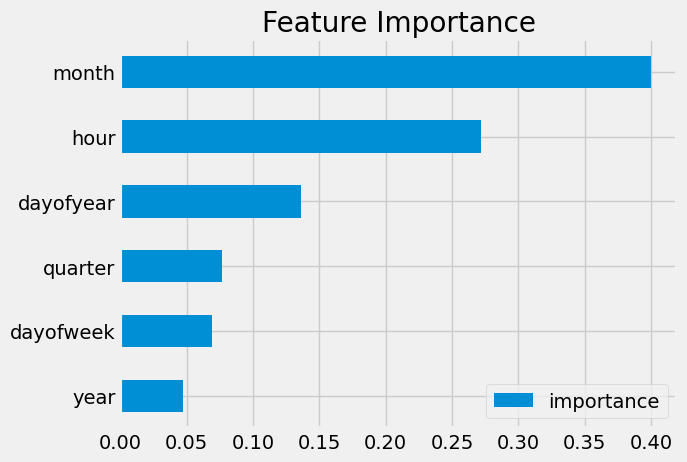

In [88]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

# Forecast on Test

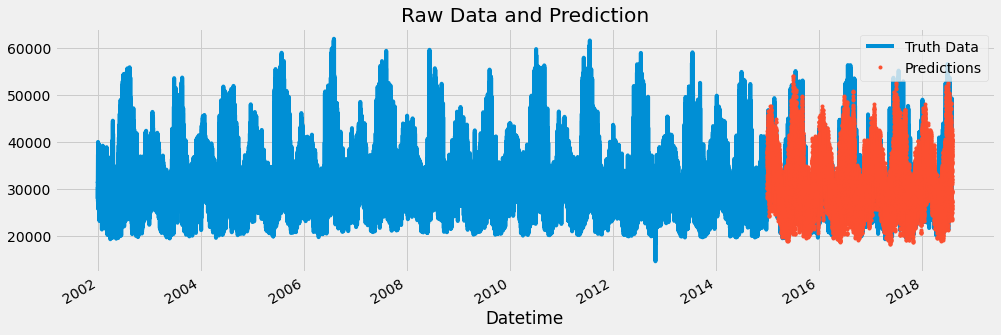

In [16]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Prediction')
plt.show()

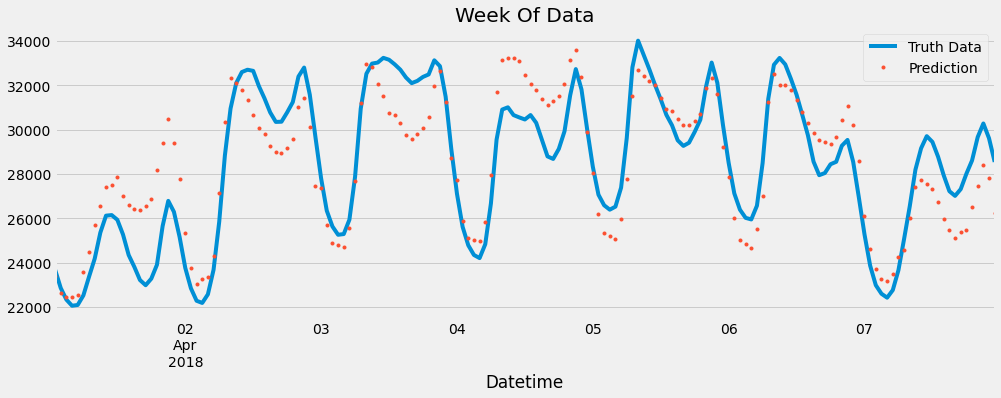

In [17]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# Score (RMSE)

In [18]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 4499.00


# Calculate Error
- Look at the worst and best predicted days

In [19]:
print(test.columns)

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'prediction'],
      dtype='object')


In [20]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

date
2016-08-13    17811.158040
2016-08-14    16171.342773
2016-08-12    14751.007568
2017-09-02    14289.224609
2017-01-25    13044.634115
2015-02-20    12629.768229
2016-08-11    12523.626628
2017-01-26    12338.819336
2015-07-19    12333.817139
2015-02-21    12291.933350
Name: error, dtype: float64

# Next Step
- More robust cross validation (part 2)
# Your Turn
- Add more features (weather forecast, holidays)

# The Next